<a href="https://colab.research.google.com/github/royssentongo/Own_projects/blob/main/Pima_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building Machine Learning Models for the Pima Diabetes Dataset

## Data Manipulation

#### Installing Libraries

In [244]:
# Installing necessary versions
#%pip install numpy==1.26.4
#%pip install pandas
#%pip install protobuf
#%pip install xgboost
#%pip install imblearn
#%pip install seaborn
#%pip install tensorflow
#%pip install sklearn
#%pip install statsmodels



#### Importing Necessary Libraries

In [245]:
# Importing necessary libraries
# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

# For manipulating Data
import pandas as pd
import numpy as np

# For visualisation
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# For Logistic statistical inferencing
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

# For splitting the data
from sklearn.model_selection import train_test_split

# For building Logistic Regressor
from sklearn.linear_model import LogisticRegression

# For building Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# For developing emsemble Classifiers
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier

# For developing XGBoost classifier
from xgboost import XGBClassifier

# For tuning the classifier models
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# For Cross Validation
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score,StratifiedKFold

# For measuring performance
from sklearn import metrics
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score
                             ,confusion_matrix,classification_report,roc_auc_score, roc_curve)

# For Oversampling and Undersampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# For imputing missing values
from sklearn.impute import SimpleImputer

# To create a pipeline and personalizing them
from imblearn.pipeline import Pipeline, make_pipeline

# To build a Neural Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


#### Loading the Dataset

In [246]:
# importing the data set from Kaggle
%pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the dataset (not a file)
file_path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

# Load the dataset using KaggleDatasetAdapter
# NOTE: You should NOT include the .csv extension when using KaggleDatasetAdapter.PANDAS

# Instead, list the files to find the actual file name
import os
print("Files downloaded:", os.listdir(file_path))

# Then load the correct file
csv_file_path = os.path.join(file_path, "diabetes.csv")  # Adjust file name if needed

import pandas as pd
data = pd.read_csv(csv_file_path)

# Preview the dataset
data.head()

Files downloaded: ['diabetes.csv']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Data Overview

In [247]:
# Checking the columns and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


All columns data types are as expected.


In [248]:
# Checking the shape
data.shape

(768, 9)

There are 9 columns and 768 rows of data

#### Description of the Data

In [249]:
# Checking the description of the dataset
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


* On average, each woman has about 3.8 pregnancies with a median of 3 pregnancies and maximum of 17.
* The minimum value in Glucose level, Blood Pressure, Skin Thickness, and BMI was 0 which seems like missing data given that there can't be a zero value in all these variables.
* The mean BMI was 31.99 which suggests on average, the sampled women were obese. Also 75% of the women sampled are considered overweight given a Normal BMI threshold of 18.5 to 24.9
* There are cases of zero Insulin levels pointing to presence of Type 1 Diabetes.
* The mean Age of the women in the sample was 33.24. This suggests that most were in their Middle Ages.

#### Checking for Missing values

In [250]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


There are no missing values in the data set

#### Checking for Duplicates

In [251]:
data.duplicated().sum()

np.int64(0)

There are no duplicated rows in the data

### Feature Engineering

In [252]:
# Creating age groups in the data ie. below 30 is youth, 31-49 is middle-aged, above 50 is Elderly
data['Age Group'] = pd.Series([])
for i in range(len(data)):
    if data.loc[i,'Age']<50:
        data.loc[i,'Age Group']='Middle-aged'
    if data.loc[i,'Age']<30:
        data.loc[i,'Age Group']='Youth'
    if data.loc[i,'Age']>49:
        data.loc[i,'Age Group']='Elderly'
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age Group
0,6,148,72,35,0,33.6,0.627,50,1,Elderly
1,1,85,66,29,0,26.6,0.351,31,0,Middle-aged
2,8,183,64,0,0,23.3,0.672,32,1,Middle-aged
3,1,89,66,23,94,28.1,0.167,21,0,Youth
4,0,137,40,35,168,43.1,2.288,33,1,Middle-aged


In [253]:
# Creating a column for Diabetic or Non-Diabetic
data['Status']=data['Outcome']
data['Status']= data['Status'].replace(1,'Diabetic')
data['Status']= data['Status'].replace(0,'Non-Diabetic')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age Group,Status
0,6,148,72,35,0,33.6,0.627,50,1,Elderly,Diabetic
1,1,85,66,29,0,26.6,0.351,31,0,Middle-aged,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,1,Middle-aged,Diabetic
3,1,89,66,23,94,28.1,0.167,21,0,Youth,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,1,Middle-aged,Diabetic


## Exploratory Data Analysis

### Univariate Analysis

In [254]:
# user function to plot Histogram and Box plot
def hist_box_plot (data,col_name, kde=False, bins=None, figsize = (8,4)):
  f2, (ax_box, ax_hist) = plt.subplots(nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},figsize=figsize,)  # creating the 2 subplots
  sns.boxplot(data=data, x=col_name, ax=ax_box, showmeans=True, color="violet")  # boxplot will be created and a star will indicate the mean value of the column
  sns.histplot(data=data, x=col_name, kde=kde, ax=ax_hist, palette="winter",
  bins=bins) if bins else sns.histplot(data=data, x=col_name, kde=kde, ax=ax_hist)  # For histogram
  ax_hist.axvline(data[col_name].mean(), color="green", linestyle="--")  # Add mean to the histogram
  ax_hist.axvline(data[col_name].median(), color="black", linestyle="-")  # Add median to the histogram

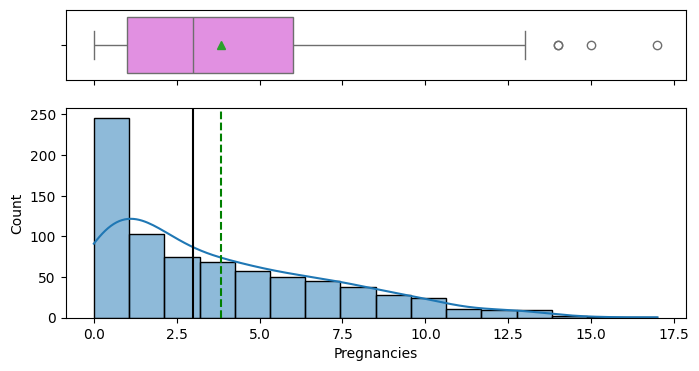

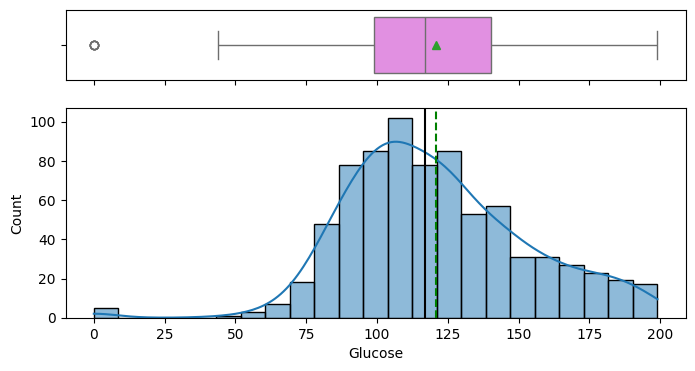

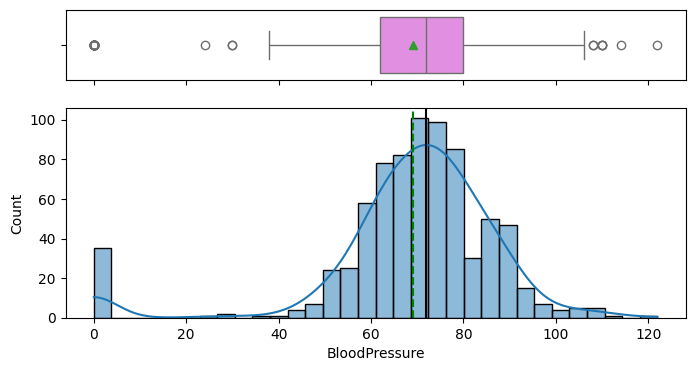

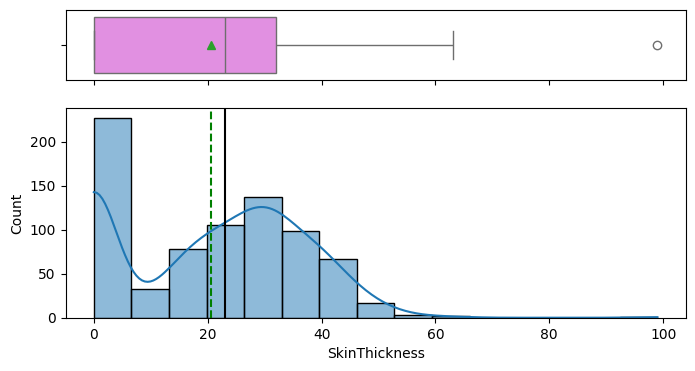

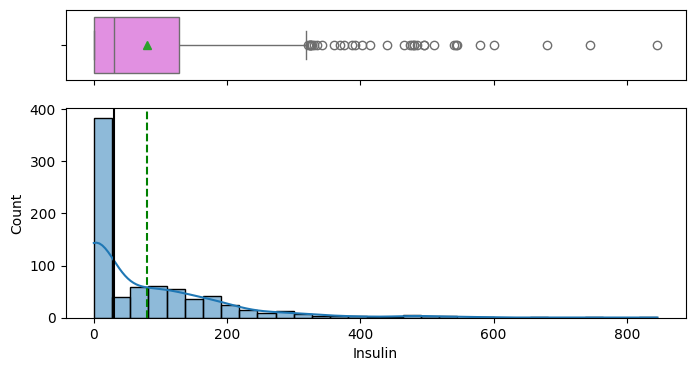

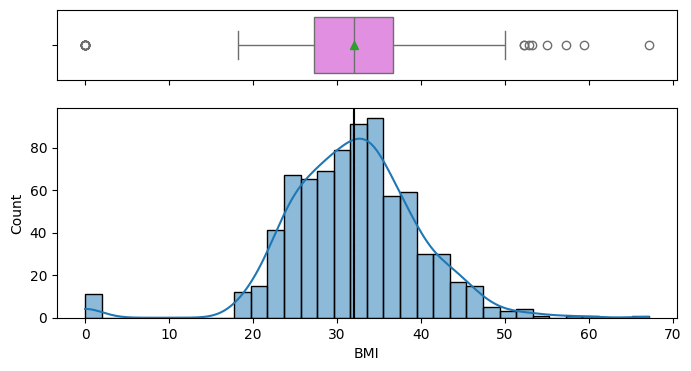

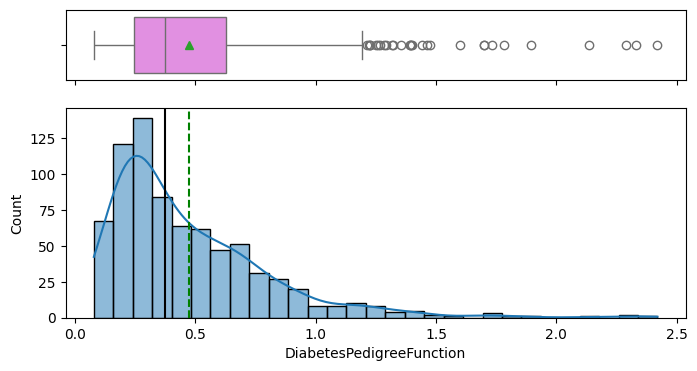

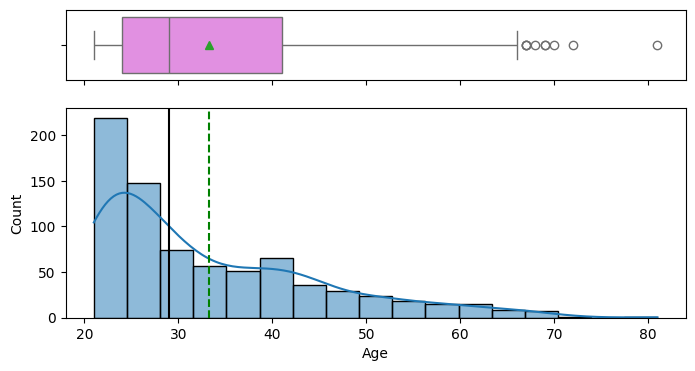

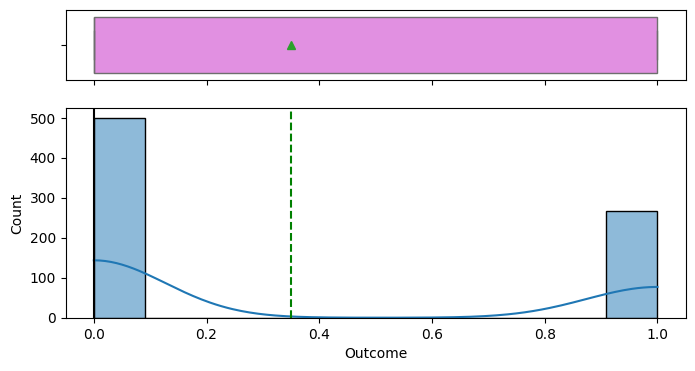

In [255]:
# Ploting histogram and box plots for all the variables
column_names = data.select_dtypes(include=np.number).columns.tolist()
for col_name in column_names:
    hist_box_plot(data,col_name,kde=True,bins=None, figsize=(8,4))

* The pregnancy values beyond 12.5 births need investigating the age to make sure they are realistic.
* Glucose, Blood Pressure and Skin thickness at Zero all need dropping given that they aren't realistically possible.
* Insulin has outliers beyond 300. These should be investigated to determine whether they are actual values.
* BMI (Body Mass Index) has a Zero value which is impossible.

###

#### Count Plot for the Age Groups

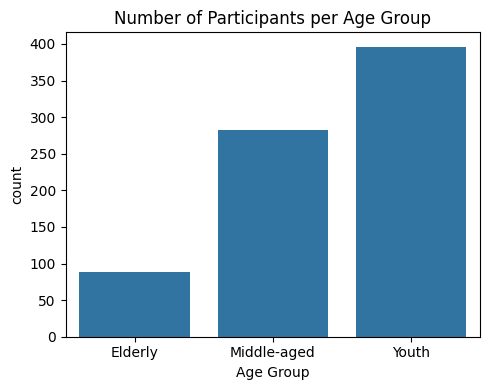

In [256]:
plt.figure(figsize=(5,4))
plt.title('Number of Participants per Age Group')
plt.xlabel('Age Group')
sns.countplot(data=data, x='Age Group');
plt.tight_layout()
plt.show()

* Youth (18-30 years) were the majority participants in the survey with the elderly (above 49) the least participating age group.

### Multivariate Analysis

#### Correlation between Variables

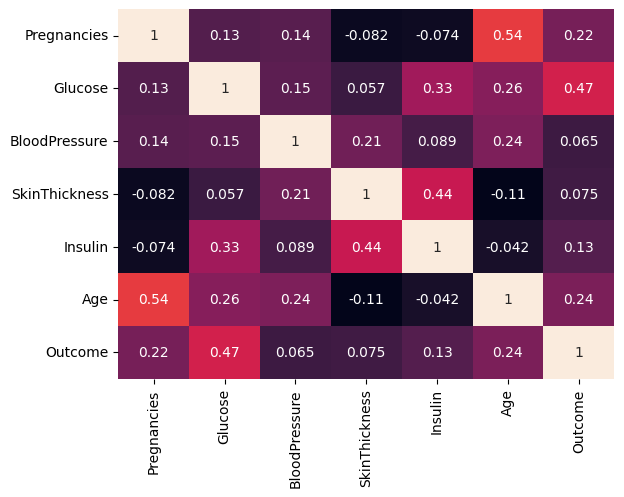

In [257]:
# Plotting Heat Map
sns.heatmap(data = data[data.select_dtypes('int','float').columns].corr(),annot=True,cbar=False);

Observations:
* Weak positive correlation between Gluscose & Insulin concentrations and Glucose & BMI.
* Moderately strong positive correlation between number of pregnacies and Age.
* Moderately strong postive correlations between Glucose level and the Outcome of Diabetic condition.
* Moderately strong correlation between Skin thickness & Insulin and Skin thickness & BMI.
* The Outcome has a weak positive correlation with Pregnancies, BMI and Age

### Multivariate Analysis

In [258]:
#function for plotting Line chart
def line_plot (df, var1, var2, ci=False):
    plt.figure(figsize = (8,4))
    plt.title(f"Line Plot showing how {var1} and {var2} varied")
    plt.xlabel(var1)
    plt.ylabel(var2)
    sns.lineplot(data = df, x= var1, y=var2, ci=ci,markers=True)
    plt.tight_layout()
    plt.show()

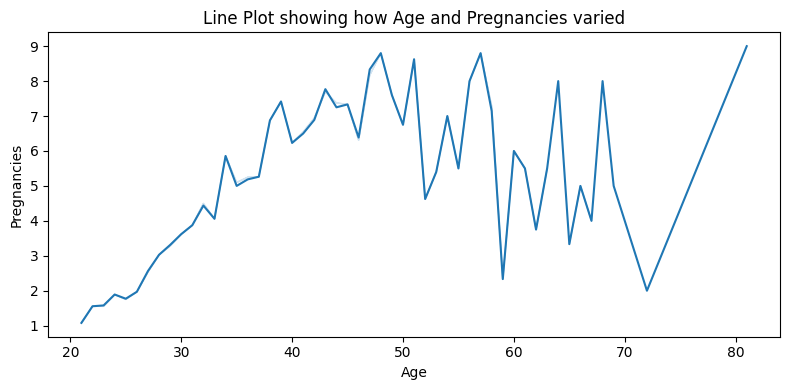

In [259]:
line_plot(data,'Age','Pregnancies',)

Older generations of women had more pregnancies than newer generations showing that the birthrates are dropping

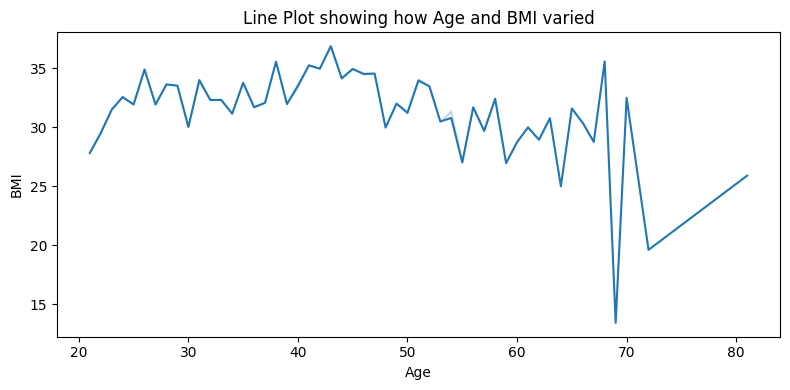

In [260]:
line_plot(data,'Age','BMI',ci=True)

* There is a general decrease in BMI with an increase in Age.
* BMI generally ranged between 25 and 35.

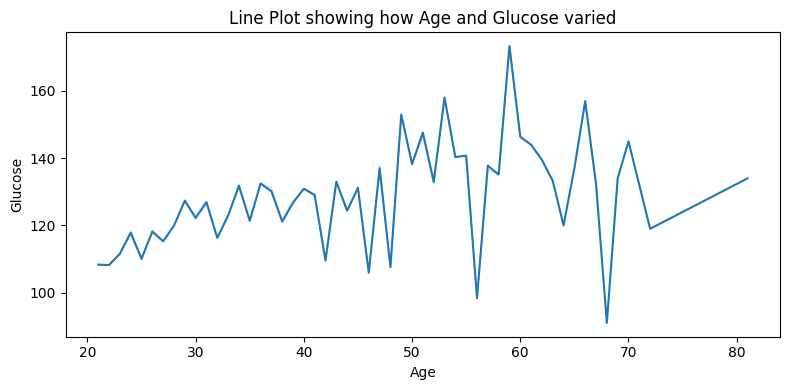

In [261]:
line_plot(data,'Age','Glucose')

* There is a general increase in the Glucose levels with an increase in Age.
* The spread in glucose levels increased after Age 50 pointing to underlying factors that influence Glucose levels like differences in Activity, Insulin levels etc.

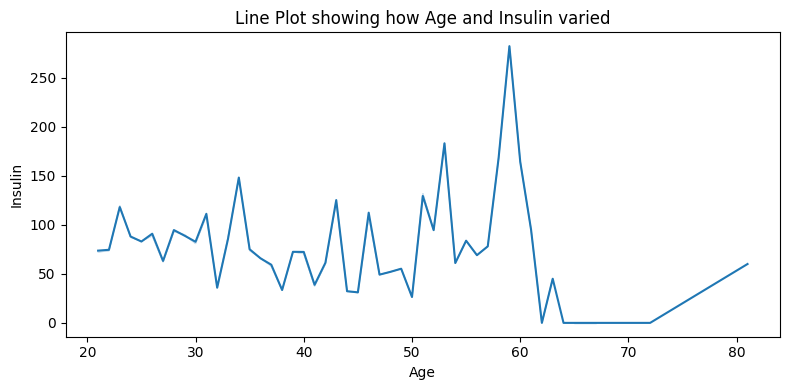

In [262]:
line_plot(data,'Age','Insulin')

In [263]:
#function for plotting count chart
def bar_plot (df, var1, var2):
    plt.figure(figsize = (8,4))
    plt.title(f"Bar Plot showing how {var1} and {var2} varied")
    plt.xlabel(var1)
    sns.barplot(data = df, x= var1, y = var2)
    plt.tight_layout()
    plt.show()

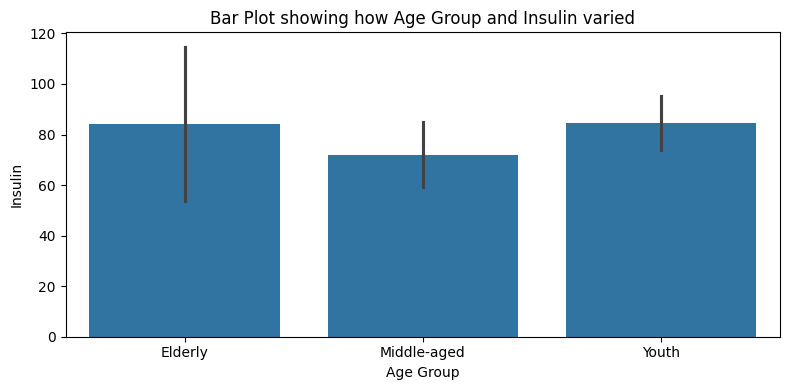

In [264]:
bar_plot (data, 'Age Group', 'Insulin')

* Youth and Middle-aged groups had the least amount of variance in Insulin levels with Elderly group having huge variance.
* Interestingly the mean Insulin levels for Elderly and Youth were very close to each other.

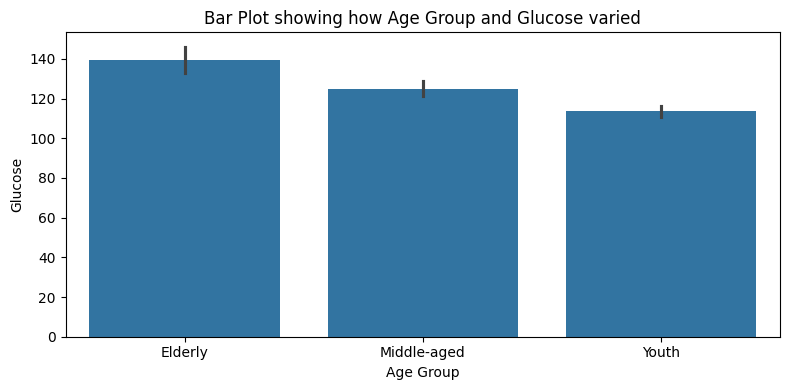

In [265]:
bar_plot (data, 'Age Group', 'Glucose')

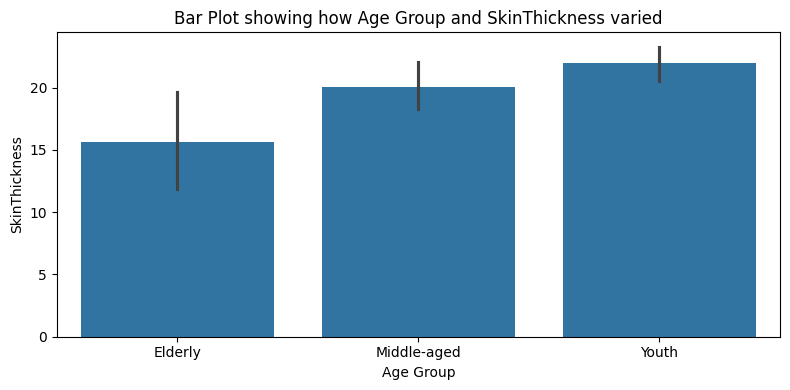

In [266]:
bar_plot (data, 'Age Group', 'SkinThickness')

In [267]:
# Function to plot box plots to visualise the distribution of numerical variables
def multiboxplot (num_val, cat_val, cat_val2):
  plt.title(f'Relationship between {cat_val}, {cat_val2} and {num_val}') #setting the plot title
  plt.xlabel(cat_val) #setting the x-axis label
  plt.ylabel(num_val) #setting the y-axis label

  sns.boxplot(x=cat_val, y=num_val,hue=cat_val2, data=data); #Plotting the chart

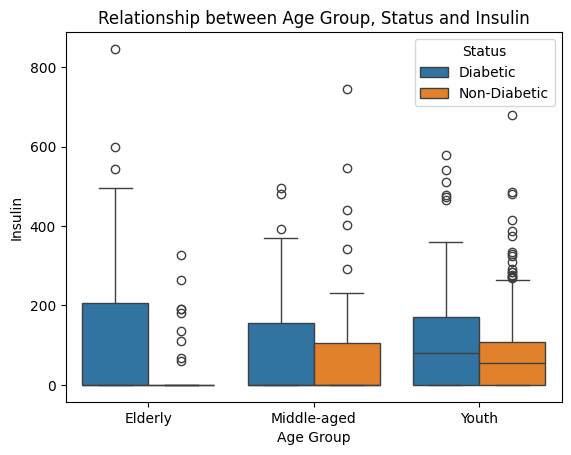

In [268]:
multiboxplot ('Insulin', 'Age Group', 'Status')

* The diabetic cases in Youth and the Elderly exhibited high insulin levels pointing to Insulin Resistance i.e. Type 2 diabetes.
* As expected, Insulin levels in Diabetic individuals was on average higher than non-diabetic individuals pointing to a likelihood of high prevalence of Type 2 diabetes.
* Non-diabetic Eldery individuals had low insulin levels pointing to a risk of Type 1 diabetes.

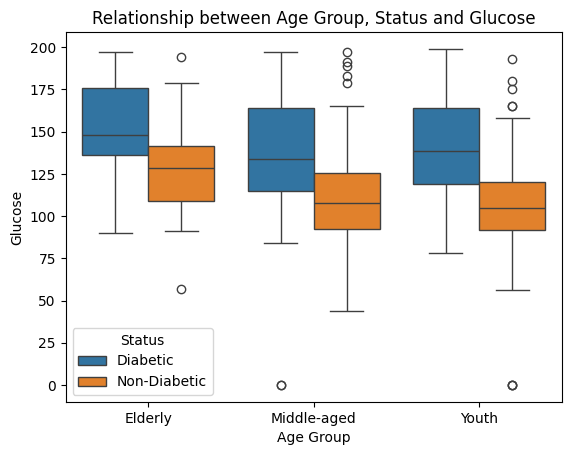

In [269]:
multiboxplot ('Glucose', 'Age Group', 'Status')

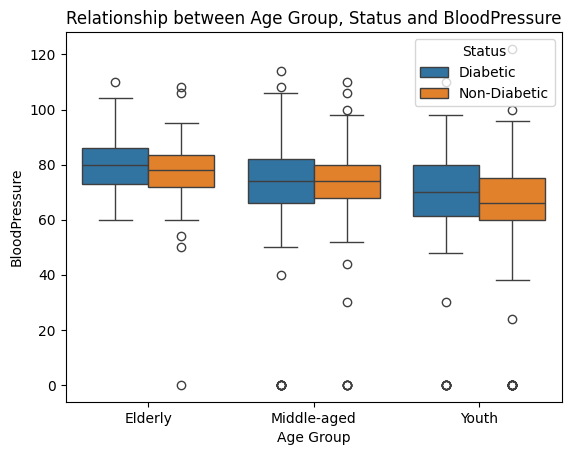

In [270]:
multiboxplot ('BloodPressure', 'Age Group', 'Status')

* The Blood Pressure generally increased with increase in Age.
* Generally, the average Blood Pressure of Diabetic individuals was higher than that of Non-diabetic individuals.

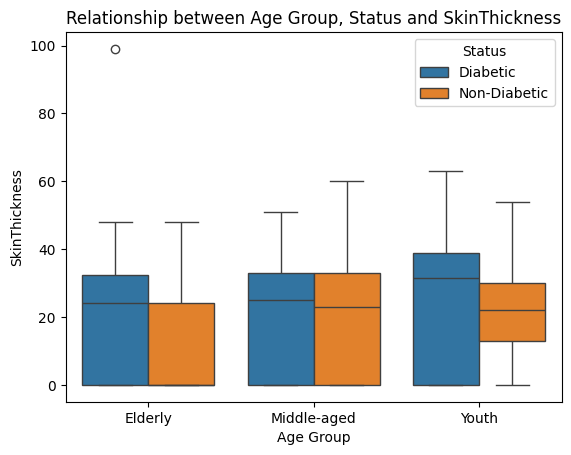

In [271]:
multiboxplot ('SkinThickness', 'Age Group', 'Status')

* The average skin Thickness of Diabetic individuals was generally higher than that of non-diabetic individuals across all the Age Groups.
* The least difference in Skin Thickness between the Diabetic and Normal individuals occurred in the Middle-aged individuals.

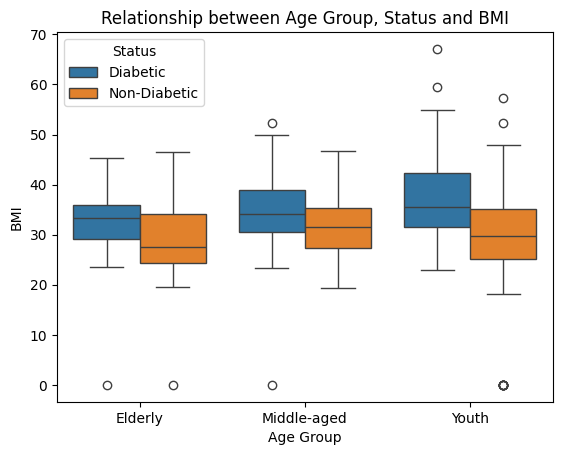

In [272]:
multiboxplot ('BMI', 'Age Group', 'Status')

* Across all Age Groups, the Normal individuals had an average BMI lower than that of their Diabetic counter parts.
*There are individuals who had a BMI of Zero which is practically impossible and therefore these values are likely errors or missing data.
* Diabetic youth were on average more obese compared to other age groups.

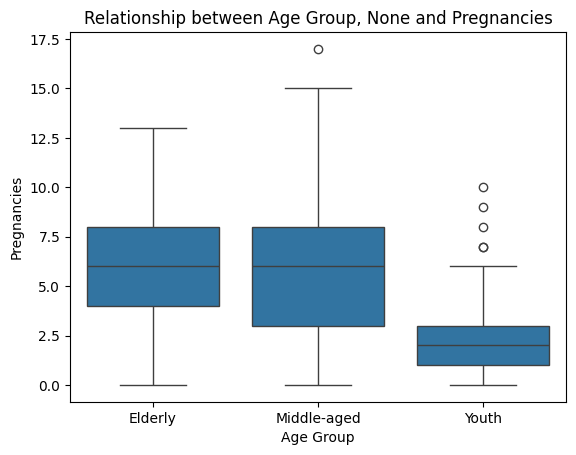

In [273]:
multiboxplot ('Pregnancies', 'Age Group', None)

* Youth had on average the lowest pregnancies.
* Elderly and Middle-aged groups ahd on average the same number of pregnancies

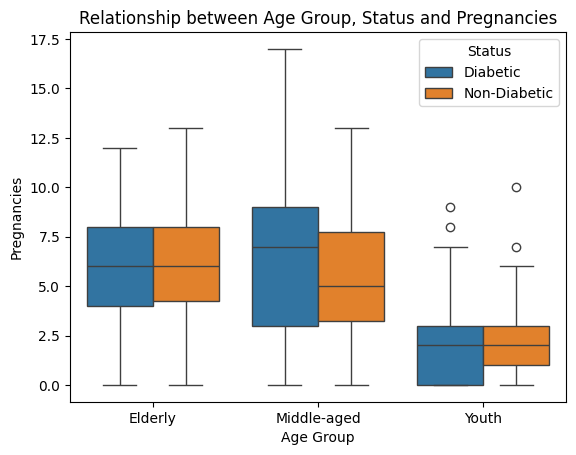

In [274]:
multiboxplot ('Pregnancies', 'Age Group', 'Status')

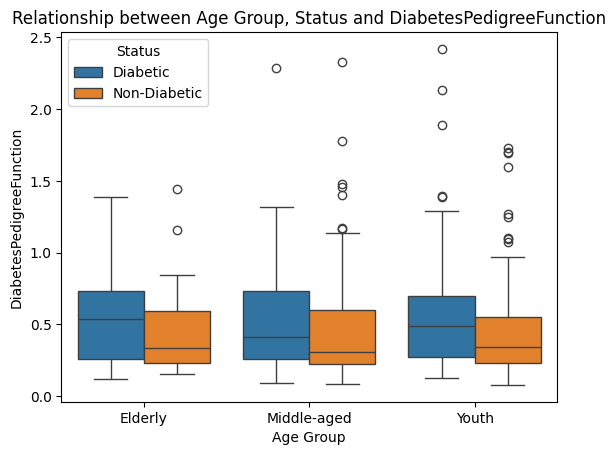

In [275]:
multiboxplot ('DiabetesPedigreeFunction', 'Age Group', 'Status')

* Diabetic individuals across all age groups had on average a higher Diabetes Pedigree Function compared to the Non-diabetic individuals.
* The average Diabetes Pedigree Function across all age groups for the Non-diabetic individuals was largely similar.

### Data Pre-processing
* Missing value treatment
* Feature engineering
* Outlier detection and treatment
* Preparing data for modeling
* Any other preprocessing steps

#### Preparing data for modelling

In [276]:
# Creating copy column of Age Group to preserve categorical variables for imputation
data['Age_Group'] = data['Age Group']

# Splitting data into predictor (x) and Target (y)
y = data['Outcome']
x=data.drop(['Outcome'],axis=1)

# Creating dummy variables
x = pd.get_dummies(x,columns=['Age_Group'],drop_first=True)

# converting dummy variables to Integer type
dummy_cols = [col for col in x.columns if col.startswith('Age_Group_')]
x[dummy_cols] = x[dummy_cols].astype(int)
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Age Group,Status,Age_Group_Middle-aged,Age_Group_Youth
0,6,148,72,35,0,33.6,0.627,50,Elderly,Diabetic,0,0
1,1,85,66,29,0,26.6,0.351,31,Middle-aged,Non-Diabetic,1,0
2,8,183,64,0,0,23.3,0.672,32,Middle-aged,Diabetic,1,0
3,1,89,66,23,94,28.1,0.167,21,Youth,Non-Diabetic,0,1
4,0,137,40,35,168,43.1,2.288,33,Middle-aged,Diabetic,1,0


In [277]:
x=x.drop('Age',axis=1) #Dropping age to eliminate its effects on models due to its high variance.

In [278]:
# Splitting the data into temp, test set
x_temp,x_test,y_temp,y_test = train_test_split(x,y,test_size=0.25,stratify=y,random_state=1)

# Viewing the proportion of Target
print('y_temp')
print(y_temp.value_counts(normalize=True))
print("-"*40)
print('y_test')
print(y_test.value_counts(normalize=True))

y_temp
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64
----------------------------------------
y_test
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [279]:
#shape of the data sets
print(y_temp.shape)
print(y_test.shape)

(576,)
(192,)


In [280]:
# Splitting x_temp into train and Validation sets
x_train,x_val,y_train,y_val = train_test_split(x_temp,y_temp,test_size=0.2,stratify=y_temp,random_state=1)

# Viewing the proportion of Target
print('y_train')
print(y_train.value_counts(normalize=True))
print("-"*40)
print('y_val')
print(y_val.value_counts(normalize=True))

y_train
Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64
----------------------------------------
y_val
Outcome
0    0.655172
1    0.344828
Name: proportion, dtype: float64


#### Missing Value Treatment
* Zero-values in Glucose, Blood Pressure, Skin Thickness and BMI are likely un-collected data points that need imputation.

In [281]:
# Target Variables for changing Zeros to Nan
columns_to_replace = ['Glucose','BloodPressure','SkinThickness','BMI']

# Function for changing Zeros in Glucose, Blood Pressure, Skin Thickness and BMI to Nan
def convertor(data_set,value_to_replace):
    data_set[columns_to_replace] = data_set[columns_to_replace].replace(value_to_replace,np.nan)
    return data_set.isnull().sum() # checking missing values in the dataset.

In [282]:
# Converting the zeros in the x_train set
convertor(data_set=x_train,value_to_replace=0)

,0
Pregnancies,0
Glucose,2
BloodPressure,15
SkinThickness,132
Insulin,0
BMI,5
DiabetesPedigreeFunction,0
Age Group,0
Status,0
Age_Group_Middle-aged,0


In [283]:
# Converting the zeros in the x_val set
convertor(data_set=x_val,value_to_replace=0)

,0
Pregnancies,0
Glucose,1
BloodPressure,7
SkinThickness,35
Insulin,0
BMI,1
DiabetesPedigreeFunction,0
Age Group,0
Status,0
Age_Group_Middle-aged,0


In [284]:
# The imputer_fit function
def imputer_fit (df, how):
    imputation_map = df.groupby(['Status','Age Group'])[columns_to_replace].agg(how) #.agg() gives us a clean mapping dataframe
    return imputation_map

In [285]:
# Fitting the imputer user-defined function on x_train
imputation_map = imputer_fit(x_train,'median')
imputation_map

Glucose  BloodPressure  SkinThickness    BMI
Status       Age Group                                                
Diabetic     Elderly        150.0           78.0           31.0  33.30
             Middle-aged    136.0           74.0           32.0  34.30
             Youth          141.0           70.0           35.0  35.55
Non-Diabetic Elderly        133.0           77.0           33.0  26.70
             Middle-aged    109.0           74.0           30.0  32.00
             Youth          106.0           66.0           25.0  30.10

In [286]:
def impute_transform (df):
    df_copy = df.copy()
    for col in columns_to_replace:
        # Use the original 'Age Group' and 'Status' columns from the 'data' DataFrame
        df_copy[col] = df_copy.apply(lambda row: imputation_map.loc[(data.loc[row.name,'Status'], data.loc[row.name,'Age Group']), col]
            if pd.isnull(row[col]) and (data.loc[row.name,'Status'], data.loc[row.name,'Age Group']) in imputation_map.index
            else row[col],axis=1)
    return df_copy

In [287]:
# Transforming the x_train with the impute_transform function
x_train = impute_transform(x_train)
x_train.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age Group,0
Status,0
Age_Group_Middle-aged,0


In [288]:
# Transforming x_val with fitting results from training
x_val = impute_transform(x_val)
x_val.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age Group,0
Status,0
Age_Group_Middle-aged,0


#### Outlier Detection and Treatment

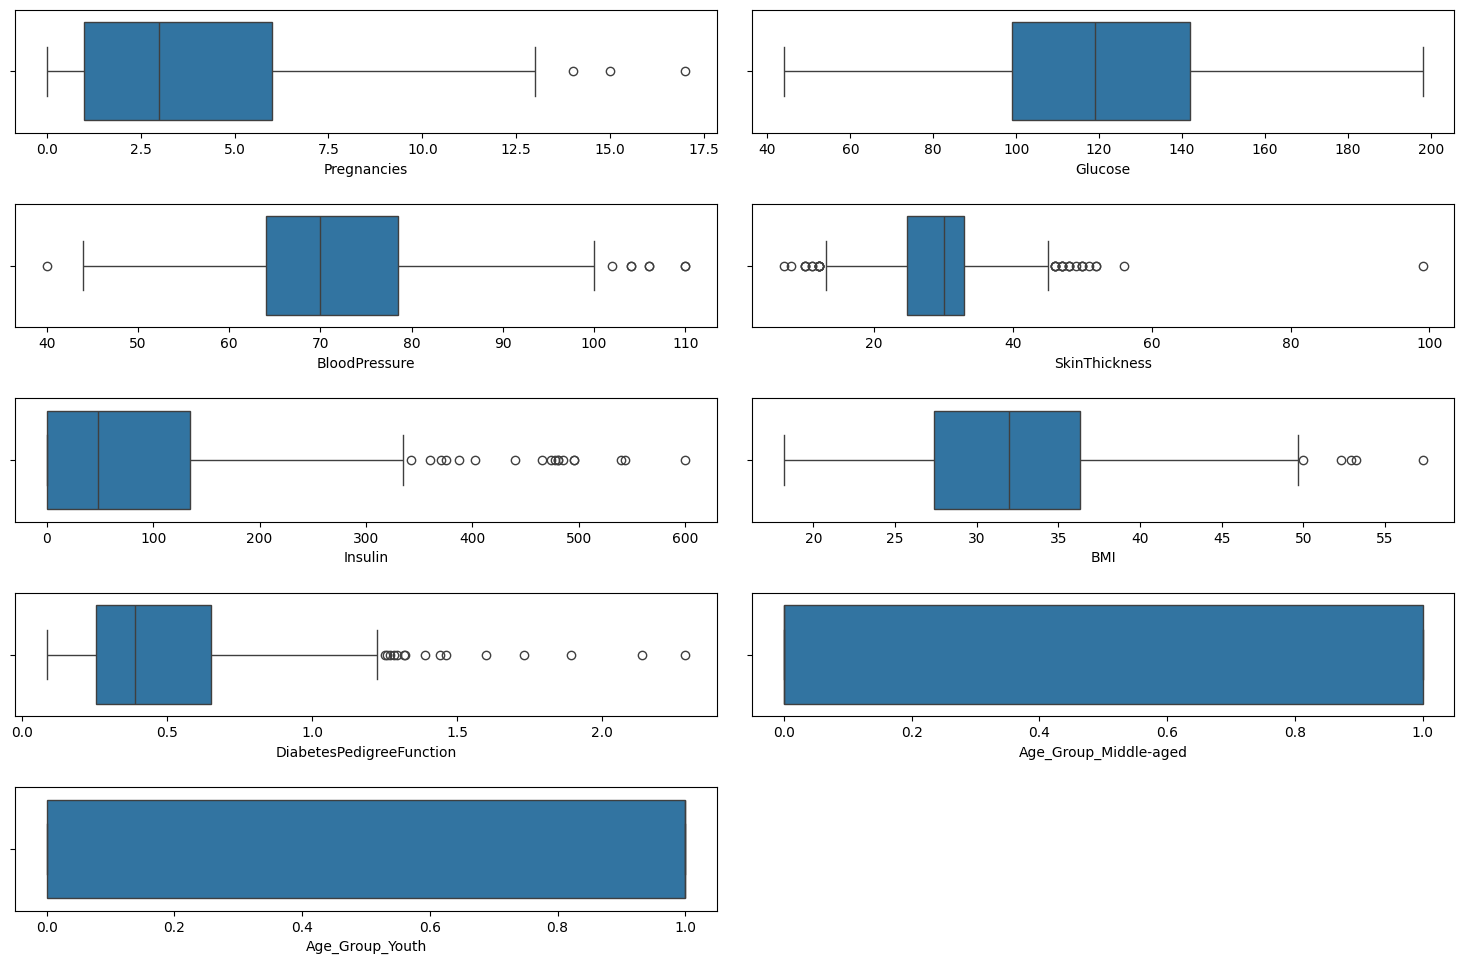

In [289]:
# Outlier detection
num_cols = x_train.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))

for i, variable in enumerate(num_cols):
    plt.subplot(5, 2, i + 1)
    sns.boxplot(data=x_train, x=variable)
    plt.tight_layout(pad=2)

plt.show()

In [290]:
# checking the data of pregnancies above 13
x_train[x_train.loc[:,'Pregnancies']>13]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age Group,Status,Age_Group_Middle-aged,Age_Group_Youth
159,17,163.0,72.0,41.0,114,40.9,0.817,Middle-aged,Diabetic,1,0
88,15,136.0,70.0,32.0,110,37.1,0.153,Middle-aged,Diabetic,1,0
455,14,175.0,62.0,30.0,0,33.6,0.212,Middle-aged,Diabetic,1,0


* All the pregnancies rates are possible and thus true values

In [291]:
# Treating Outliers of Glucose value of 0 to the Q1-1.5*IQR point.
'''Why IQR instead of x_bar-2std: Because x_bar-2std assume the data is normally distributed
& 95% of the data is contained in that'''

# Computing the 25th and 75th quantiles
def treat_outliers (col,Q1=False,Q3=False):
    lower_quantile = x_temp[col].quantile(0.25) # 25th percentile
    upper_quantile = x_temp[col].quantile(0.75) # 75th percentile
    IQR = upper_quantile-lower_quantile

    # Computing the values of the lower & upper Whiskers
    lower_whisker = lower_quantile-1.5*IQR
    upper_whisker = upper_quantile+1.5*IQR

    # Clipping the outliers
    if Q1==True & Q3==True:
        x_train[col] = x_train[col].clip(lower=lower_whisker,upper=upper_whisker)
    elif Q1==True:
        x_train[col] = x_train[col].clip(lower=lower_whisker,upper=None)
    elif Q3==True:
        x_train[col] = x_train[col].clip(lower=None,upper=upper_whisker)
    else:
        x_train[col] = x_train[col].clip(lower=Q1,upper=Q3)

    plt.figure(figsize=(5,3))
    sns.boxplot(data=x_train, x=col)
    plt.tight_layout(pad=2)
    plt.show()


##### Treating Outliers in Blood Pressure Variable
* No outliers were treated because all the values are within a possible range and could hold important predictive information

##### Treating Outliers in SkinThickness Variable

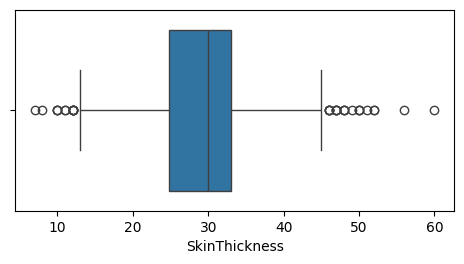

In [292]:
treat_outliers ('SkinThickness',Q1=None,Q3=60)

##### Treating Outliers in Insulin Variable.
* Capping at 400 because beyond this, it's a health emergency thereby signaling that values beyond that won't add any information for our models however could be noise.


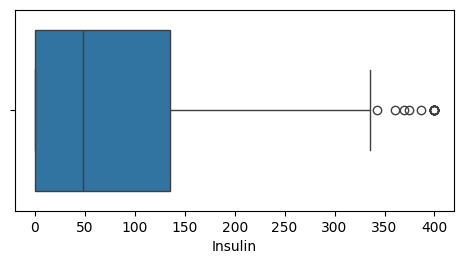

In [293]:
treat_outliers ('Insulin',Q1=None,Q3=400)

##### Treating Outliers in BMI:
* Will not be treating the outliers beyond BMI of 40 because they all represent Class 3 Obesity and could hold important information for our prediction models.

##### Treating Outliers in Diabetes Pedigree Function variable
* No outliers shall be treated given that they are all within the acceptable range of the Diabetes Pedigree Function.

#### Dropping the 'Status'and 'Age Group' Columns
Dropped because the information in it is already captured under Outcome and dummy variables

In [294]:
# Dropping Status and Age Group columns from x_train, x_val, and x_test
dfs = [x_train, x_val, x_test]
df_names = ['x_train', 'x_val', 'x_test']

for i in range(len(dfs)):
    # Select columns with object dtype
    object_cols = dfs[i].select_dtypes('object').columns
    # Drop the object columns and reassign to the original variable
    globals()[df_names[i]] = dfs[i].drop(object_cols, axis=1)
    print(f"Columns after dropping object types in {df_names[i]}:")
    print(globals()[df_names[i]].columns)

Columns after dropping object types in x_train:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age_Group_Middle-aged',
       'Age_Group_Youth'],
      dtype='object')
Columns after dropping object types in x_val:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age_Group_Middle-aged',
       'Age_Group_Youth'],
      dtype='object')
Columns after dropping object types in x_test:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age_Group_Middle-aged',
       'Age_Group_Youth'],
      dtype='object')


#### EDA after Data Preprocessing

In [295]:
# Checking the description
x_train.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,460.0,3.813043,3.334615,0.000,1.000,3.0000,6.00000,17.000
Glucose,460.0,122.660870,31.340185,44.000,99.000,119.0000,142.00000,198.000
BloodPressure,460.0,71.765217,11.745731,40.000,64.000,70.0000,78.50000,110.000
SkinThickness,460.0,29.282609,8.750134,7.000,24.750,30.0000,33.00000,60.000
Insulin,460.0,82.360870,104.702131,0.000,0.000,48.5000,135.00000,400.000
BMI,460.0,32.323043,6.815450,18.200,27.375,32.0000,36.32500,57.300
DiabetesPedigreeFunction,460.0,0.482324,0.329071,0.084,0.254,0.3895,0.64975,2.288
Age_Group_Middle-aged,460.0,0.369565,0.483213,0.000,0.000,0.0000,1.00000,1.000
Age_Group_Youth,460.0,0.506522,0.500502,0.000,0.000,1.0000,1.00000,1.000


### Statistical Inferencing

#### Model Building
The model will interprete True Positives (TP) as the individuals correctly identified as diabetic, False Positives (FP) as indiviuals wrongly classified as diabetic.

Recall = TP/(TP+FN) shall be our measure of model performance.

### Logistic Regression
Running and training a Logistic statistical regression to evaluate the odds of being diabetic given a given parameter

#### Data Preprocessing for Logistic regression

In [296]:
# Adding a constant to train set
X_stat_train = sm.add_constant(x_train)
Y_stat_train = y_train

# Adding a constant to validation set
X_stat_val = sm.add_constant(x_val)
Y_stat_val = y_val

#Adding a constant to test set
X_stat_test = sm.add_constant(x_test)
Y_stat_test = y_test


#### Testing for Multicollinearity

In [297]:
# Getting the VIF for each variable
vif_series = pd.Series([variance_inflation_factor(X_stat_train.values, i) for i in range(X_stat_train.shape[1])],
    index=X_stat_train.columns)
print("Series before feature selection: \n\n{}\n".format(vif_series))

Series before feature selection: 

const                       84.198468
Pregnancies                  1.597203
Glucose                      1.315310
BloodPressure                1.270191
SkinThickness                1.543097
Insulin                      1.190673
BMI                          1.657159
DiabetesPedigreeFunction     1.051800
Age_Group_Middle-aged        2.750991
Age_Group_Youth              3.777252
dtype: float64



There is no multicollinearity given that all numerical variables have a VIF below 5

#### Checking for high p-values

In [298]:
# Running Logistic regression
Logit = sm.Logit(Y_stat_train,X_stat_train)
lg = Logit.fit()
print(lg.summary())

Optimization terminated successfully.
         Current function value: 0.436896
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  460
Model:                          Logit   Df Residuals:                      450
Method:                           MLE   Df Model:                            9
Date:                Sun, 24 Aug 2025   Pseudo R-squ.:                  0.3252
Time:                        15:30:55   Log-Likelihood:                -200.97
converged:                       True   LL-Null:                       -297.83
Covariance Type:            nonrobust   LLR p-value:                 6.897e-37
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -9.1045      1.248     -7.293      0.000     -11.551

In [299]:
# Dropping High p-value variables
# initial list of columns
cols = X_stat_train.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    X_stat_train_aux = X_stat_train[cols]

    # fitting the model
    model = sm.Logit(Y_stat_train, X_stat_train_aux).fit(disp=False)

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age_Group_Youth']


In [300]:
# Logistic regreesion after dropping Highest p-value variables
X_stat_train2 = X_stat_train[selected_features]
X_stat_test2 = X_stat_test[selected_features]
Logit2 = sm.Logit(Y_stat_train,X_stat_train2)
lg2 = Logit.fit()
print(lg2.summary())

Optimization terminated successfully.
         Current function value: 0.436896
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  460
Model:                          Logit   Df Residuals:                      450
Method:                           MLE   Df Model:                            9
Date:                Sun, 24 Aug 2025   Pseudo R-squ.:                  0.3252
Time:                        15:30:56   Log-Likelihood:                -200.97
converged:                       True   LL-Null:                       -297.83
Covariance Type:            nonrobust   LLR p-value:                 6.897e-37
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -9.1045      1.248     -7.293      0.000     -11.551

Observations:
* An increase in the levels of Glucose, BMI or Diabetes Pedigree Function all increased the probability of being Diabetic
* Being a Youth i.e. 29 years old and below reduced the probability of being Diabetic.

In [301]:
# converting coefficients to odds
odds = np.exp(lg2.params)

# finding the percentage change
perc_change_odds = (np.exp(lg2.params) - 1) * 100

# removing limit from number of columns to display
pd.set_option("display.max_columns", None)

# adding the odds to a dataframe
pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_stat_train2.columns).T

,const,Glucose,BMI,DiabetesPedigreeFunction,Age_Group_Youth
Odds,0.000111,1.041704,1.095383,2.960636,0.513250
Change_odd%,-99.988883,4.170371,9.538273,196.063573,-48.674985


### Decision Tree Model

#### Preparing Data for Modeling

##### Scaling the numerical variables

In [51]:
# Scaling the Independent Variables

# to use the standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Listing the numerical columns
num_cols = x_train.select_dtypes(exclude='object').columns
# Fitting and transforming x_train
x_train[num_cols]=scaler.fit_transform(x_train[num_cols])

# Transforming x_val
x_val[num_cols]=scaler.transform(x_val[num_cols])
